In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

In [6]:
best_model = joblib.load('PKL_Modelo/best_model.pkl')
preprocessor = joblib.load('PKL_datos/preprocessor.pkl')
results = joblib.load('PKL_Modelo/model_results.pkl')

X_train_raw, X_test_raw, y_train, y_test = joblib.load('PKL_datos/splits_raw.pkl')

print('Mejor modelo:', type(best_model).__name__)
print('X_test shape:', X_test_raw.shape)

Mejor modelo: RandomForestRegressor
X_test shape: (751, 7)


In [8]:
# Predicción con pipeline completo (raw → preprocesar → predecir)
X_test_prep = preprocessor.transform(X_test_raw)
y_pred_log  = best_model.predict(X_test_prep)

# Revertir log-transform
y_pred_usd = np.expm1(y_pred_log)
y_test_usd = np.expm1(y_test)

rmse = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))
mae  = mean_absolute_error(y_test_usd, y_pred_usd)
r2   = r2_score(y_test_usd, y_pred_usd)

print('MÉTRICAS DEL MEJOR MODELO (en USD)')
print(f'R²:   {r2:.4f} explica el {r2*100:.1f}% de la varianza del salario')
print(f'RMSE: ${rmse:,.0f} error promedio cuadrático')
print(f'MAE:  ${mae:,.0f} error absoluto promedio')

MÉTRICAS DEL MEJOR MODELO (en USD)
R²:   0.3910 explica el 39.1% de la varianza del salario
RMSE: $49,034 error promedio cuadrático
MAE:  $36,169 error absoluto promedio


## Métrica más importante y por qué

**Para este problema la métrica más importante es el MAE (Mean Absolute Error)**

**¿Por qué?**
- El MAE representa el error promedio en **dólares reales**, fácil de interpretar para negocio.
- Un MAE de \$15,000 significa que en promedio el modelo se equivoca \$15,000 en su predicción — esto es directamente accionable.
- El RMSE penaliza fuertemente los errores grandes (outliers de salario muy alto), lo que puede distorsionar la evaluación.
- El R² indica qué tan bien explica el modelo la varianza, pero no dice cuánto se equivoca en términos monetarios.

**En contexto de negocio:** una empresa que usa este modelo para ofertas salariales necesita saber *cuántos dólares* puede estar errando, no un índice abstracto.

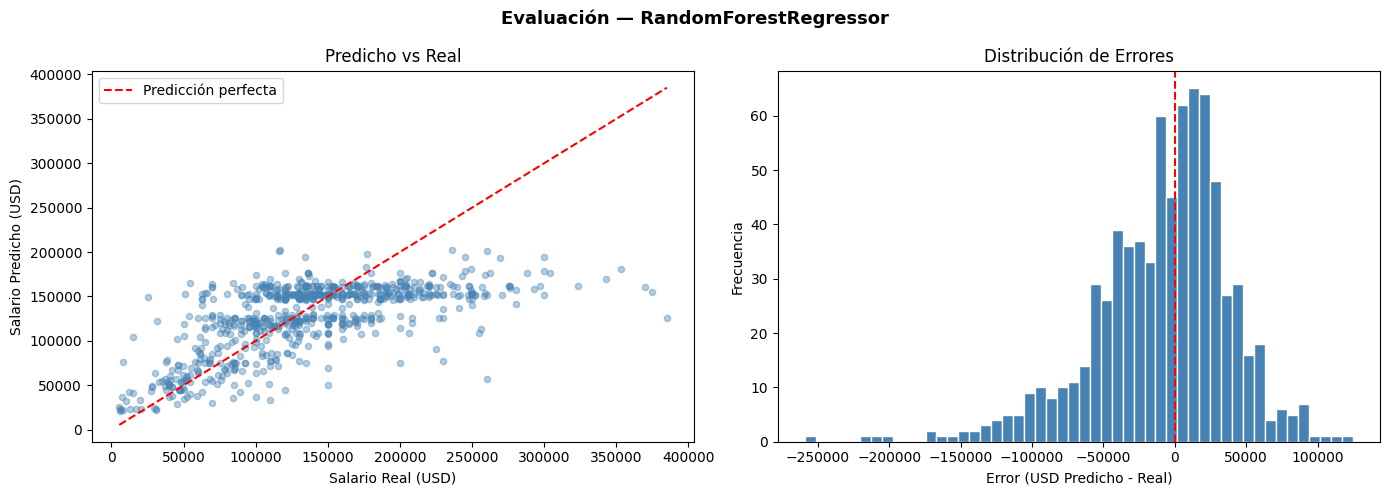

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicho vs Real
axes[0].scatter(y_test_usd, y_pred_usd, alpha=0.4, color='steelblue', s=20)
lims = [min(y_test_usd.min(), y_pred_usd.min()),
        max(y_test_usd.max(), y_pred_usd.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Salario Real (USD)')
axes[0].set_ylabel('Salario Predicho (USD)')
axes[0].set_title('Predicho vs Real')
axes[0].legend()

# Distribución de errores
errores = y_pred_usd - y_test_usd
axes[1].hist(errores, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Error (USD Predicho - Real)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Errores')

plt.suptitle(f'Evaluación — {type(best_model).__name__}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/eval_predicho_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

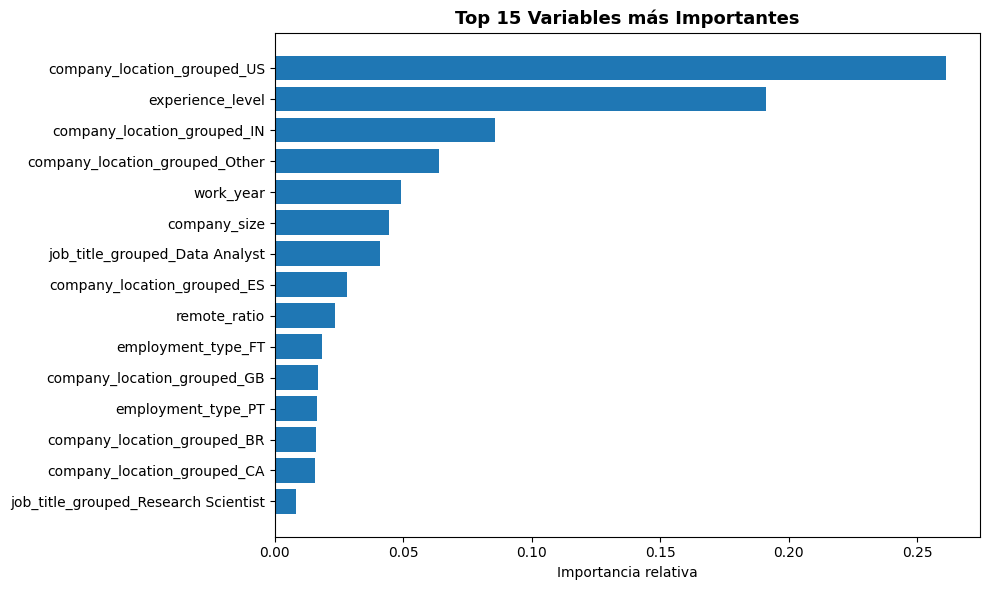

Top 5 variables más influyentes:
  company_location_grouped_US: 0.2614
  experience_level: 0.1911
  company_location_grouped_IN: 0.0856
  company_location_grouped_Other: 0.0638
  work_year: 0.0490


In [12]:
if hasattr(best_model, 'feature_importances_'):
    feature_names = []
    for name, transformer, cols in preprocessor.transformers_:
        if hasattr(transformer, 'get_feature_names_out'):
            feature_names.extend(transformer.get_feature_names_out(cols).tolist())
        else:
            feature_names.extend(cols if isinstance(cols, list) else [cols])

    importances = pd.Series(best_model.feature_importances_, index=feature_names)
    top15 = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    #colors = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(top15))]
    plt.barh(top15.index[::-1], top15.values[::-1])#, #color=colors[::-1])
    plt.title('Top 15 Variables más Importantes', fontsize=13, fontweight='bold')
    plt.xlabel('Importancia relativa')
    plt.tight_layout()
    plt.savefig('images/eval_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Top 5 variables más influyentes:')
    for feat, imp in top15.head(5).items():
        print(f'  {feat}: {imp:.4f}')
else:
    print('El modelo no tiene feature_importances_')
    print('Usa los coeficientes del modelo lineal para interpretar.')

## ¿Vale la pena usar el modelo en producción?

**Respuesta:** Depende del contexto, pero en general **sí vale la pena como herramienta de apoyo**.

**Argumentos a favor:**
- Un R² > 0.6 significa que el modelo captura más del 60% de los factores que determinan el salario — útil como referencia.
- El MAE en USD da un rango concreto de error que RRHH puede usar para negociación salarial.
- Es mucho más objetivo que la intuición humana — elimina sesgos de negociación.
- Escalable: puede evaluar miles de perfiles en segundos.

**Limitaciones a considerar:**
- El dataset es predominantemente de empresas de USA — puede no aplicar bien a otros mercados.
- No captura factores como habilidades específicas, reputación del candidato o coyuntura económica.
- **Recomendación:** usarlo como piso/techo de referencia, no como decisión final.

In [13]:
# Pipeline que une preprocesador + modelo en un solo objeto
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_model)
])

# Prueba con un ejemplo real
ejemplo = pd.DataFrame([{
    'work_year': 2023,
    'experience_level': 'SE',
    'employment_type': 'FT',
    'job_title': 'Data Scientist',
    'company_location': 'US',
    'remote_ratio': 100,
    'company_size': 'M',
    'job_title_grouped': 'Data Scientist',
    'company_location_grouped': 'US'
}])

pred_log = final_pipeline.predict(ejemplo)
pred_usd = np.expm1(pred_log)[0]

print(f'Predicción para Data Scientist Senior, FT, US, remoto 100%, empresa mediana:')
print(f'  Salario estimado: ${pred_usd:,.0f} USD/año')

Predicción para Data Scientist Senior, FT, US, remoto 100%, empresa mediana:
  Salario estimado: $161,854 USD/año


In [16]:
joblib.dump(final_pipeline, 'PKL_Pipeline/pipeline.pkl')
print('Este pipeline recibe datos crudos (sin transformar) y devuelve el salario en USD.')
print('Es el único archivo que necesita FastAPI para hacer predicciones.')

Este pipeline recibe datos crudos (sin transformar) y devuelve el salario en USD.
Es el único archivo que necesita FastAPI para hacer predicciones.
